<a href="https://colab.research.google.com/github/shivanivanitha0-dev/wpt/blob/main/Boston.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df=pd.read_csv("/content/boston.csv")
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
from sklearn.metrics import mean_squared_error,mean_absolute_error
print(df)

        CRIM  INDUS    NOX     RM        AGE     DIS  TAX         PT  \
0    0.00632   2.31  0.538  6.575  65.199997  4.0900  296  15.300000   
1    0.02731   7.07  0.469  6.421  78.900002  4.9671  242  17.799999   
2    0.02729   7.07  0.469  7.185  61.099998  4.9671  242  17.799999   
3    0.03237   2.18  0.458  6.998  45.799999  6.0622  222  18.700001   
4    0.06905   2.18  0.458  7.147  54.200001  6.0622  222  18.700001   
..       ...    ...    ...    ...        ...     ...  ...        ...   
501  0.06263  11.93  0.573  6.593  69.099998  2.4786  273  21.000000   
502  0.04527  11.93  0.573  6.120  76.699997  2.2875  273  21.000000   
503  0.06076  11.93  0.573  6.976  91.000000  2.1675  273  21.000000   
504  0.10959  11.93  0.573  6.794  89.300003  2.3889  273  21.000000   
505  0.04741  11.93  0.573  6.030  80.800003  2.5050  273  21.000000   

              B         MV  
0    396.899994  24.000000  
1    396.899994  21.600000  
2    392.829987  34.700001  
3    394.630005  33

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CRIM    506 non-null    float64
 1   INDUS   506 non-null    float64
 2   NOX     506 non-null    float64
 3   RM      506 non-null    float64
 4   AGE     506 non-null    float64
 5   DIS     506 non-null    float64
 6   TAX     506 non-null    int64  
 7   PT      506 non-null    float64
 8   B       506 non-null    float64
 9   MV      506 non-null    float64
dtypes: float64(9), int64(1)
memory usage: 39.7 KB
None


In [ ]:
df.head()

,CRIM,INDUS,NOX,RM,AGE,DIS,TAX,PT,B,MV
0,0.00632,2.31,0.538,6.575,65.199997,4.0900,296,15.300000,396.899994,24.000000
1,0.02731,7.07,0.469,6.421,78.900002,4.9671,242,17.799999,396.899994,21.600000
2,0.02729,7.07,0.469,7.185,61.099998,4.9671,242,17.799999,392.829987,34.700001
3,0.03237,2.18,0.458,6.998,45.799999,6.0622,222,18.700001,394.630005,33.400002
4,0.06905,2.18,0.458,7.147,54.200001,6.0622,222,18.700001,396.899994,36.200001


In [ ]:
df.isnull().sum()

,0
CRIM,0
INDUS,0
NOX,0
RM,0
AGE,0
DIS,0
TAX,0
PT,0
B,0
MV,0


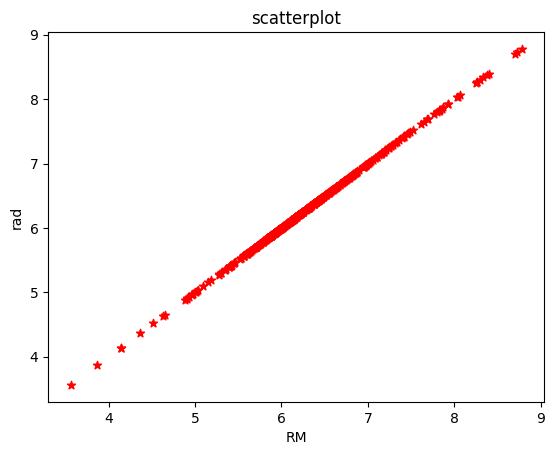

In [ ]:
plt.scatter(df.RM,df.RM,color='red',marker='*')
plt.xlabel('RM')
plt.ylabel('rad')
plt.title('scatterplot')
plt.show()

In [ ]:
x=df.drop('RM',axis=1)
print(x)

        CRIM  INDUS    NOX        AGE     DIS  TAX         PT           B  \
0    0.00632   2.31  0.538  65.199997  4.0900  296  15.300000  396.899994   
1    0.02731   7.07  0.469  78.900002  4.9671  242  17.799999  396.899994   
2    0.02729   7.07  0.469  61.099998  4.9671  242  17.799999  392.829987   
3    0.03237   2.18  0.458  45.799999  6.0622  222  18.700001  394.630005   
4    0.06905   2.18  0.458  54.200001  6.0622  222  18.700001  396.899994   
..       ...    ...    ...        ...     ...  ...        ...         ...   
501  0.06263  11.93  0.573  69.099998  2.4786  273  21.000000  391.989990   
502  0.04527  11.93  0.573  76.699997  2.2875  273  21.000000  396.899994   
503  0.06076  11.93  0.573  91.000000  2.1675  273  21.000000  396.899994   
504  0.10959  11.93  0.573  89.300003  2.3889  273  21.000000  393.450012   
505  0.04741  11.93  0.573  80.800003  2.5050  273  21.000000  396.899994   

            MV  
0    24.000000  
1    21.600000  
2    34.700001  
3    33

In [ ]:
y=df.RM
print(y)

0      6.575
1      6.421
2      7.185
3      6.998
4      7.147
       ...  
501    6.593
502    6.120
503    6.976
504    6.794
505    6.030
Name: RM, Length: 506, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=1)
print("xtrain shape:", xtrain.shape)
print("xtest shape:", xtest.shape)
print("ytrain shape:", ytrain.shape)
print("ytest shape:", ytest.shape)

xtrain shape: (404, 9)
xtest shape: (102, 9)
ytrain shape: (404,)
ytest shape: (102,)


In [ ]:
reg=linear_model.LinearRegression()
reg.fit(xtrain,ytrain)
y_pred=reg.predict(xtest)
print(reg.coef_)
print(reg.intercept_)
z=9.7900215*650+1128.879253617697
print(z)
train_score=reg.score(xtrain,ytrain)
test_score=reg.score(xtest,ytest)
print('train_score(x_squarred):',train_score)
print('test_score(r_squarred):',test_score)
mse=mean_squared_error(ytest,y_pred)
print('Mean sqaured error:',mse)
mae=mean_absolute_error(ytest,y_pred)
print('Mean absolute error:',mae)


[ 0.00241428 -0.01732657 -0.03732513  0.00242774  0.02846679  0.00049373
 -0.01407776 -0.00064994  0.05157799]
5.329546862089435
7492.393228617697
train_score(x_squarred): 0.47976506823871456
test_score(r_squarred): 0.6160869973668721
Mean sqaured error: 0.21589917130164202
Mean absolute error: 0.3455943143071906
